# Single-Core Query Analysis: QueryA vs QueryB RAPL Comparison

This notebook analyzes single-core query timing results with grouped comparisons between queryA and queryB variants.
Data includes per-run RAPL energy measurements and query execution times.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import re
import glob

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load runs CSV
runs_df = pd.read_csv('logs/query_timing_single_core.csv')
print(f'Loaded {len(runs_df)} runs')
print(f'Columns: {list(runs_df.columns)}')
print(f'\nShape: {runs_df.shape}')
print(f'\nFirst few rows:')
display(runs_df.head())
print(f'\nData types:')
print(runs_df.dtypes)

Loaded 30 runs
Columns: ['timestamp_utc', 'run_id', 'test_name', 'loop_index', 'loops', 'runs_per_loop', 'total_runs', 'total_elapsed_sec', 'failures', 'rapl_package_j', 'rapl_core_j', 'rapl_gpu_j', 'rapl_dram_j', 'query_dir', 'query_filter', 'sigless_addr', 'run_started_utc']

Shape: (30, 17)

First few rows:


,timestamp_utc,run_id,test_name,loop_index,loops,runs_per_loop,total_runs,total_elapsed_sec,failures,rapl_package_j,rapl_core_j,rapl_gpu_j,rapl_dram_j,query_dir,query_filter,sigless_addr,run_started_utc
0,2026-04-20T11:53:09Z,69AA2ADD470A714C,APX1145-queryA.sql,1,1,100,100,111.184968,0,1198.718079,1086.431030,NaN,NaN,queries,APX1145,127.0.0.1:8000,2026-04-20T11:51:18Z
1,2026-04-20T11:54:45Z,69AA2ADD470A714C,APX1145-queryB.sql,1,1,100,100,80.708590,0,894.681702,810.347534,NaN,NaN,queries,APX1145,127.0.0.1:8000,2026-04-20T11:51:18Z
2,2026-04-20T12:14:59Z,43145F4150C4811F,APX1145-queryA.sql,1,1,100,100,109.027071,0,1185.679993,1076.446655,NaN,NaN,queries,APX1145,127.0.0.1:8000,2026-04-20T12:13:10Z
3,2026-04-20T12:16:35Z,43145F4150C4811F,APX1145-queryB.sql,1,1,100,100,80.661811,0,894.705078,810.303101,NaN,NaN,queries,APX1145,127.0.0.1:8000,2026-04-20T12:13:10Z
4,2026-04-20T12:34:59Z,F7D202A0F76CE402,APX1145-queryA.sql,1,1,100,100,110.456227,0,1197.014221,1085.705444,NaN,NaN,queries,APX1145,127.0.0.1:8000,2026-04-20T12:33:08Z



Data types:
timestamp_utc         object
run_id                object
test_name             object
loop_index             int64
loops                  int64
runs_per_loop          int64
total_runs             int64
total_elapsed_sec    float64
failures               int64
rapl_package_j       float64
rapl_core_j          float64
rapl_gpu_j           float64
rapl_dram_j          float64
query_dir             object
query_filter          object
sigless_addr          object
run_started_utc       object
dtype: object


## Load and Inspect Per-Run RAPL Samples

In [19]:
# List available sample files
sample_dir = Path('logs/single_core_logs')
sample_files = sorted(sample_dir.glob('*.rapl.csv'))
print(f'Found {len(sample_files)} RAPL sample files')
print(f'\nSample file names (first 5):')
for f in sample_files[:5]:
    print(f'  {f.name}')

Found 2624 RAPL sample files

Sample file names (first 5):
  AAB8C9E87643BCA5__APX1145-queryA.sql__loop1_run1.rapl.csv
  AAB8C9E87643BCA5__APX1145-queryA.sql__loop1_run10.rapl.csv
  AAB8C9E87643BCA5__APX1145-queryA.sql__loop1_run100.rapl.csv
  AAB8C9E87643BCA5__APX1145-queryA.sql__loop1_run11.rapl.csv
  AAB8C9E87643BCA5__APX1145-queryA.sql__loop1_run12.rapl.csv


In [3]:
def load_sample(filepath):
    """
    Load a RAPL CSV file and pivot per-metric rows into wide format columns.
    Returns a dataframe with timestamp_sec and energy columns (pkg, cores, gpu, ram).
    """
    df = pd.read_csv(filepath, header=None, comment='#')
    df.columns = ['timestamp_sec', 'value', 'unit', 'metric', 'counter', 'pct', 'col6', 'col7']
    
    # Pivot: each metric becomes a column
    # Extract metric short names
    df['metric_short'] = df['metric'].str.extract(r'energy-([a-z]+)')[0]
    
    # For each timestamp, we have multiple metrics; pivot to wide format
    pivoted = df.pivot_table(
        index='timestamp_sec',
        columns='metric_short',
        values='value',
        aggfunc='first'  # In case of duplicates, take first
    )
    pivoted.reset_index(inplace=True)
    pivoted.columns.name = None  # Remove the columns index name
    
    # Rename columns for clarity
    rename_map = {'cores': 'cores_j', 'dram': 'dram_j', 'gpu': 'gpu_j', 'pkg': 'pkg_j'}
    pivoted.rename(columns=rename_map, inplace=True)
    
    return pivoted

# Test on a sample file
sample_test = load_sample(sample_files[0])
print(f'Loaded sample with shape {sample_test.shape}')
print(f'Columns: {list(sample_test.columns)}')
print(f'\nFirst few rows:')
display(sample_test.head())

Loaded sample with shape (927, 5)
Columns: ['timestamp_sec', 'cores_j', 'gpu_j', 'pkg_j', 'ram']

First few rows:


,timestamp_sec,cores_j,gpu_j,pkg_j,ram
0,0.001066,0.02,0.0,0.02,0.0
1,0.003855,0.01,0.0,0.02,0.0
2,0.006178,0.01,0.0,0.01,0.0
3,0.007337,0.01,0.0,0.02,0.0
4,0.010962,0.02,0.0,0.02,0.0


## Compare QueryA vs QueryB at Run Level by Test Name

Test groups: ['APX1090', 'APX1092', 'APX1130', 'APX1145', 'APX1173', 'APX1186', 'APX1225', 'APX1278', 'PE002', 'PE017', 'PE019']

Runs per test group:
test_group
APX1090     2
APX1092     2
APX1130     2
APX1145    10
APX1173     2
APX1186     2
APX1225     2
APX1278     2
PE002       2
PE017       2
PE019       2
dtype: int64


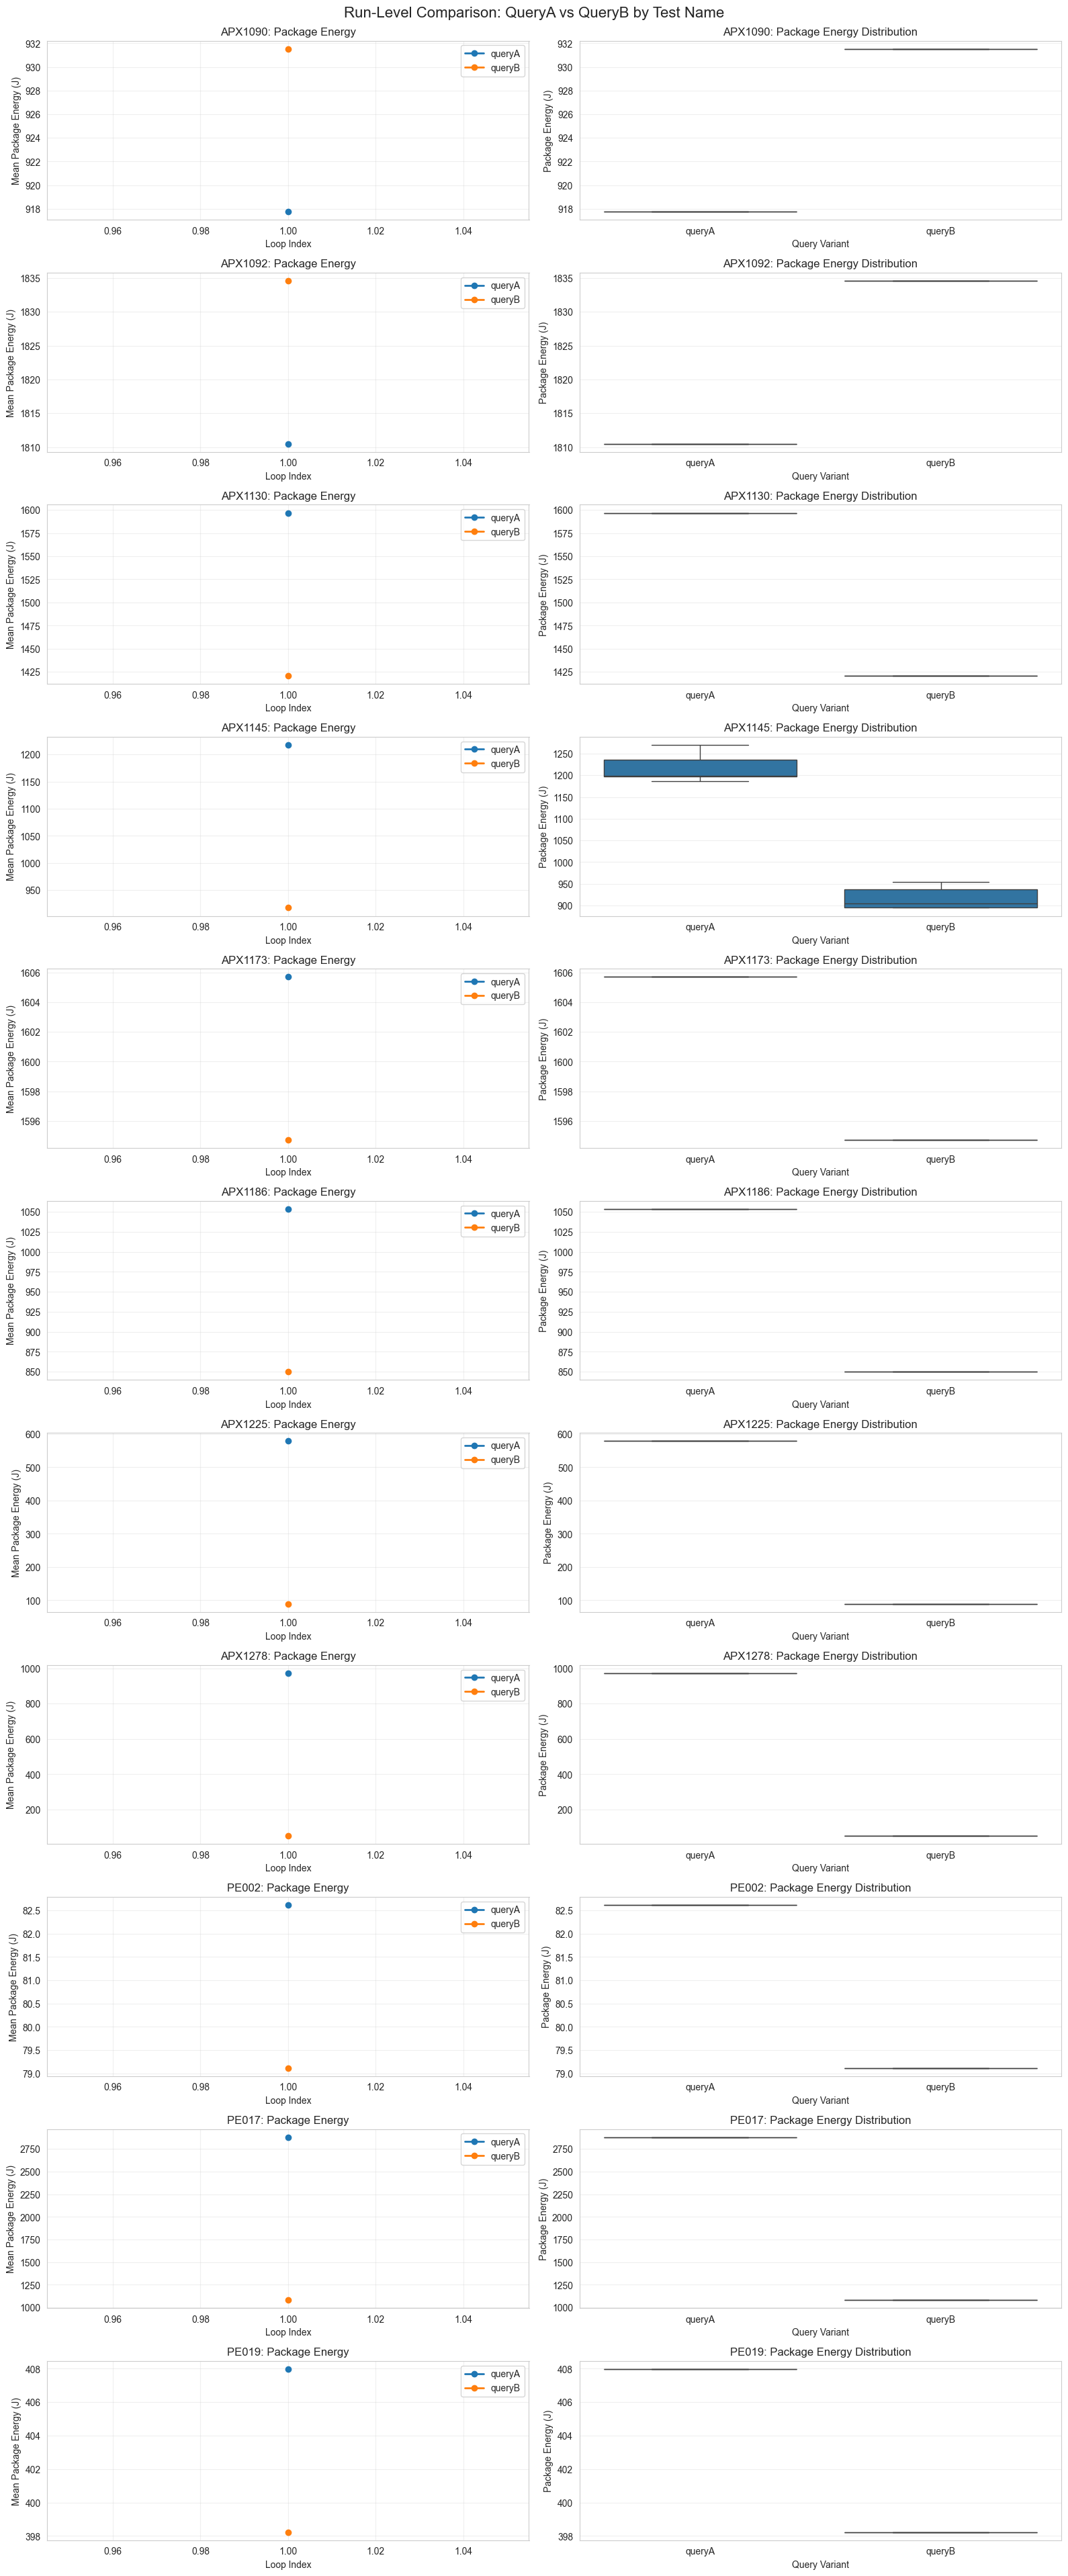

Run-level comparison plot generated.


In [4]:
# Extract query variant and test group from test_name and query_filter
runs_df['query_variant'] = runs_df['test_name'].str.extract(r'(query[AB])')
runs_df['test_group'] = runs_df['test_name'].str.extract(r'^([A-Z0-9]+)-')[0]  # APX1090, APX1145, PE002, etc.

# Get unique test groups and their counts
test_groups = sorted(runs_df['test_group'].unique())
print(f'Test groups: {test_groups}')
print(f'\nRuns per test group:')
print(runs_df.groupby('test_group').size())

# Create figure with subplots for each test group
fig, axes = plt.subplots(len(test_groups), 2, figsize=(16, 3.5 * len(test_groups)), squeeze=False)
fig.suptitle('Run-Level Comparison: QueryA vs QueryB by Test Name', fontsize=16, y=0.995)

for idx, tg in enumerate(test_groups):
    test_data = runs_df[runs_df['test_group'] == tg].copy()
    
    # Left plot: Mean energy and time by loop
    ax_left = axes[idx, 0]
    grouped = test_data.groupby(['loop_index', 'query_variant']).agg({
        'rapl_package_j': 'mean',
        'total_elapsed_sec': 'mean'
    }).reset_index()
    
    for variant in ['queryA', 'queryB']:
        var_data = grouped[grouped['query_variant'] == variant]
        if len(var_data) > 0:
            ax_left.plot(var_data['loop_index'], var_data['rapl_package_j'], 
                         marker='o', label=variant, linewidth=2)
    ax_left.set_xlabel('Loop Index')
    ax_left.set_ylabel('Mean Package Energy (J)')
    ax_left.set_title(f'{tg}: Package Energy')
    ax_left.legend()
    ax_left.grid(True, alpha=0.3)
    
    # Right plot: Box plots for distribution
    ax_right = axes[idx, 1]
    sns.boxplot(data=test_data, x='query_variant', y='rapl_package_j', ax=ax_right)
    ax_right.set_xlabel('Query Variant')
    ax_right.set_ylabel('Package Energy (J)')
    ax_right.set_title(f'{tg}: Package Energy Distribution')
    ax_right.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('Run-level comparison plot generated.')

## Compare QueryA vs QueryB Per-Millisecond RAPL by Test Name

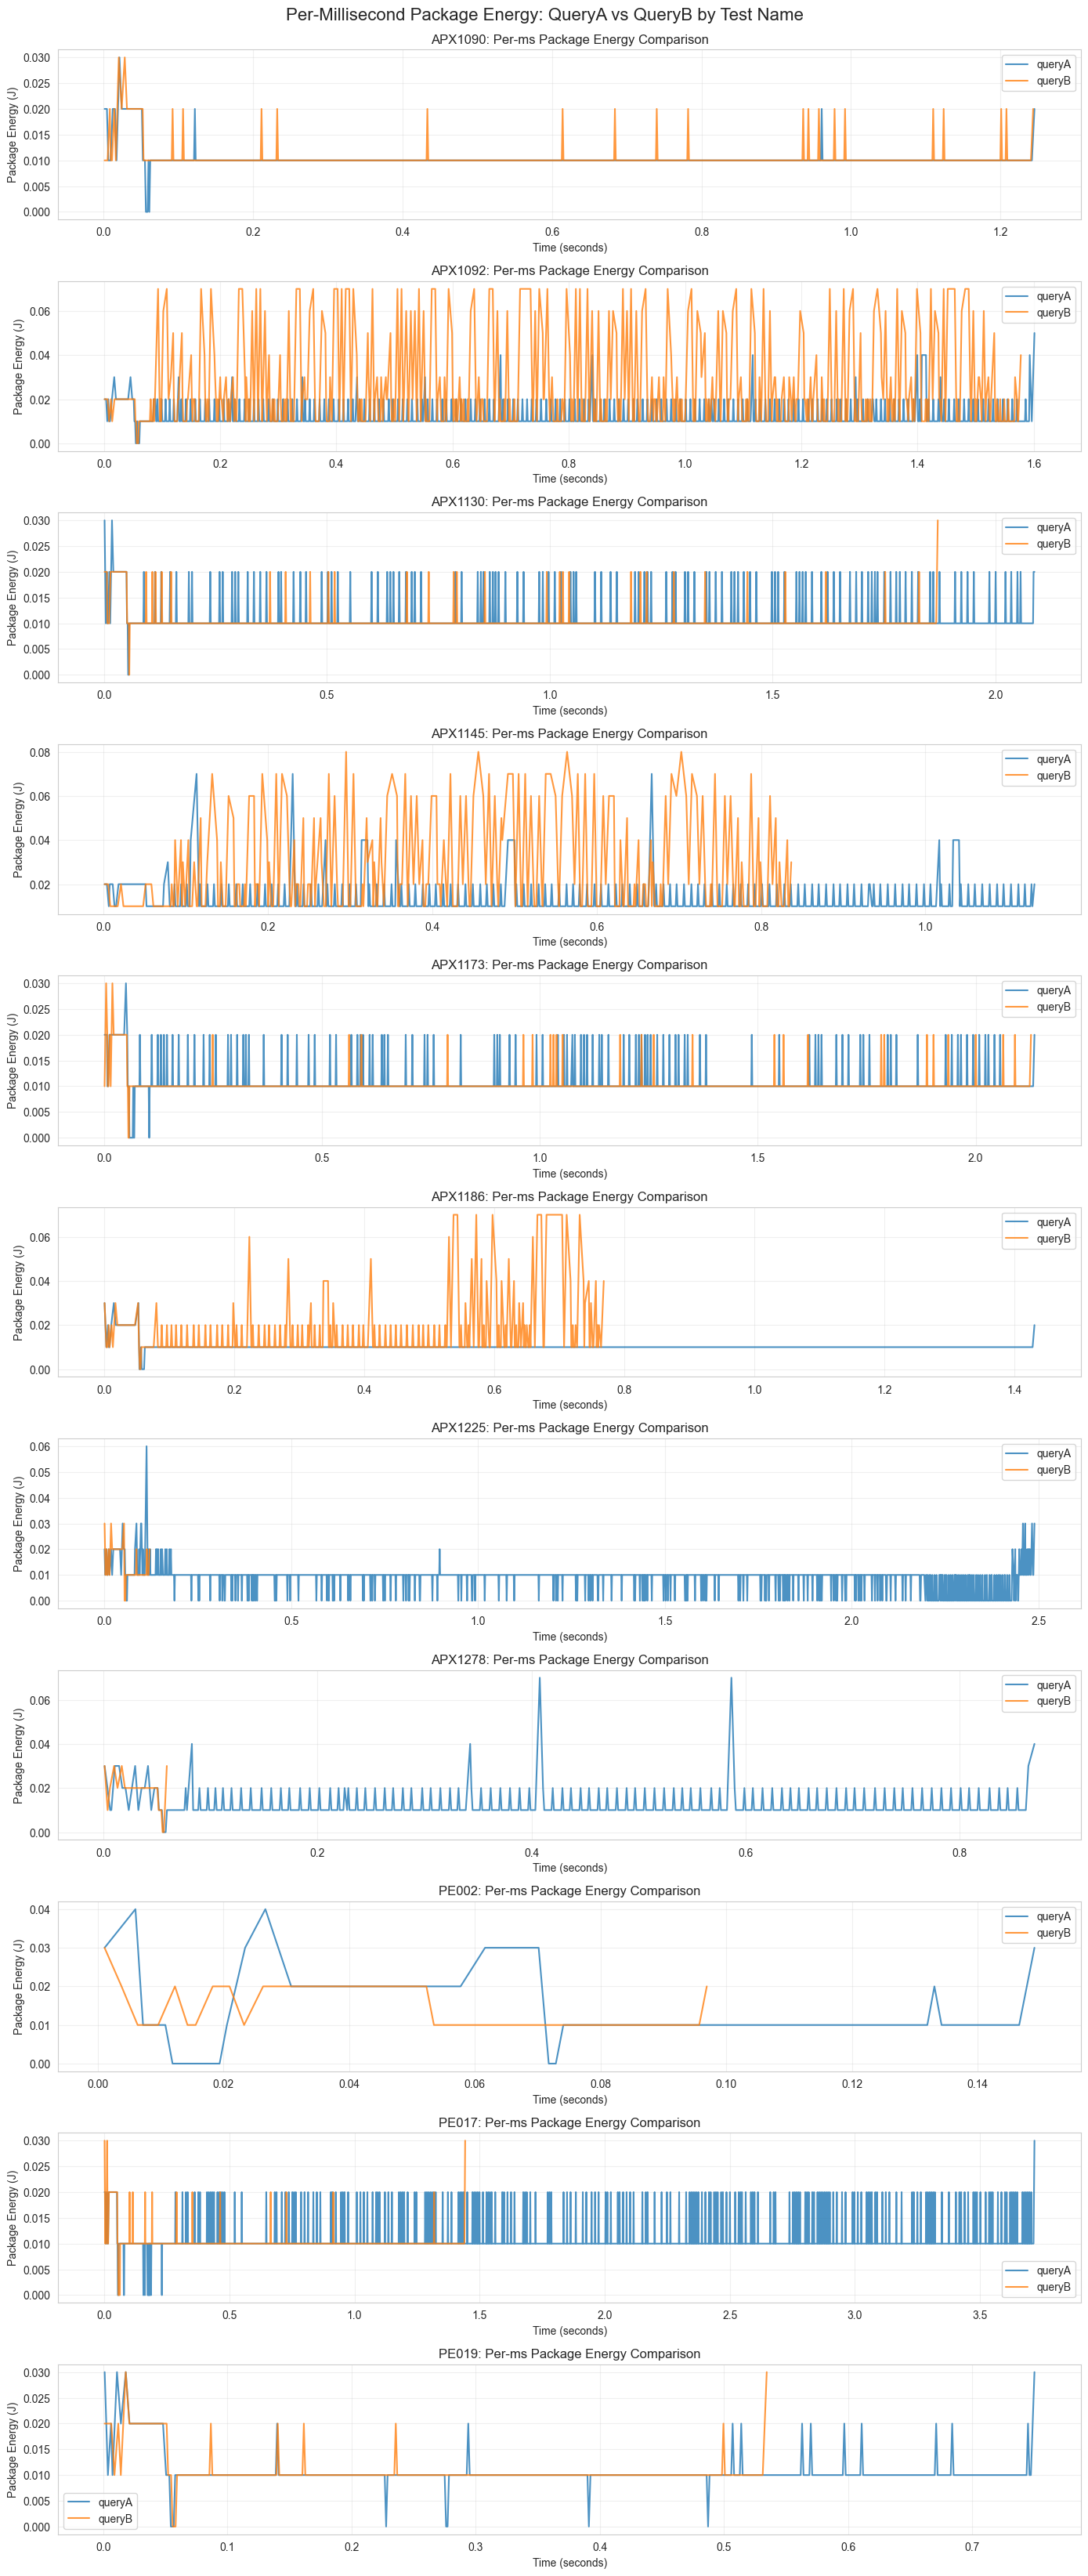

Per-ms comparison plot generated.


In [5]:
# Extract machine_id and test_group from RAPL filename
# Format: B108631FEBA1ECD4__APX1090-queryA.sql__loop1_run1.rapl.csv

def extract_from_filename(fname):
    """
    Extract machine_id, test_name, and variant from RAPL filename.
    Format: MACHINE_ID__QUERY_NAME__loopX_runY.rapl.csv
    """
    match = re.match(r'([A-F0-9]+)__(.+)__(loop\d+_run\d+)\.rapl\.csv', fname)
    if match:
        machine_id, query_name, run_info = match.groups()
        variant = 'queryA' if 'queryA' in query_name else 'queryB'
        test_group = query_name.split('-')[0]
        return machine_id, query_name, variant, test_group, run_info
    return None, None, None, None, None

# Build lookup of test_group -> sample files
test_group_samples = {}
for sample_file in sample_files:
    machine_id, query_name, variant, test_group, run_info = extract_from_filename(sample_file.name)
    if test_group:
        if test_group not in test_group_samples:
            test_group_samples[test_group] = {'queryA': [], 'queryB': []}
        test_group_samples[test_group][variant].append(sample_file)

# For each test group, plot first queryA and first queryB
n_groups = len(test_group_samples)
fig, axes = plt.subplots(n_groups, 1, figsize=(14, 3 * n_groups), squeeze=False)
fig.suptitle('Per-Millisecond Package Energy: QueryA vs QueryB by Test Name', fontsize=16, y=0.995)

for idx, (tg, variants) in enumerate(sorted(test_group_samples.items())):
    ax = axes[idx, 0]
    
    # Load first available queryA and queryB samples
    if variants['queryA']:
        qa_data = load_sample(variants['queryA'][0])
        ax.plot(qa_data['timestamp_sec'], qa_data['pkg_j'], label='queryA', linewidth=1.5, alpha=0.8)
    
    if variants['queryB']:
        qb_data = load_sample(variants['queryB'][0])
        ax.plot(qb_data['timestamp_sec'], qb_data['pkg_j'], label='queryB', linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Package Energy (J)')
    ax.set_title(f'{tg}: Per-ms Package Energy Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Per-ms comparison plot generated.')

## Full-Loop Window Comparison (1-Second Binned Energy)

Test groups in B108631FEBA1ECD4 files: ['APX1090', 'APX1092', 'APX1130', 'APX1145', 'APX1173', 'APX1186', 'APX1225', 'APX1278', 'PE002', 'PE017', 'PE019']
Expected test groups: ['APX1090', 'APX1092', 'APX1130', 'APX1145', 'APX1173', 'APX1186', 'APX1225', 'APX1278', 'PE002', 'PE017', 'PE019']
Found representative runs for 11 test groups
Starting plot 1: 100-bin single-run comparison...


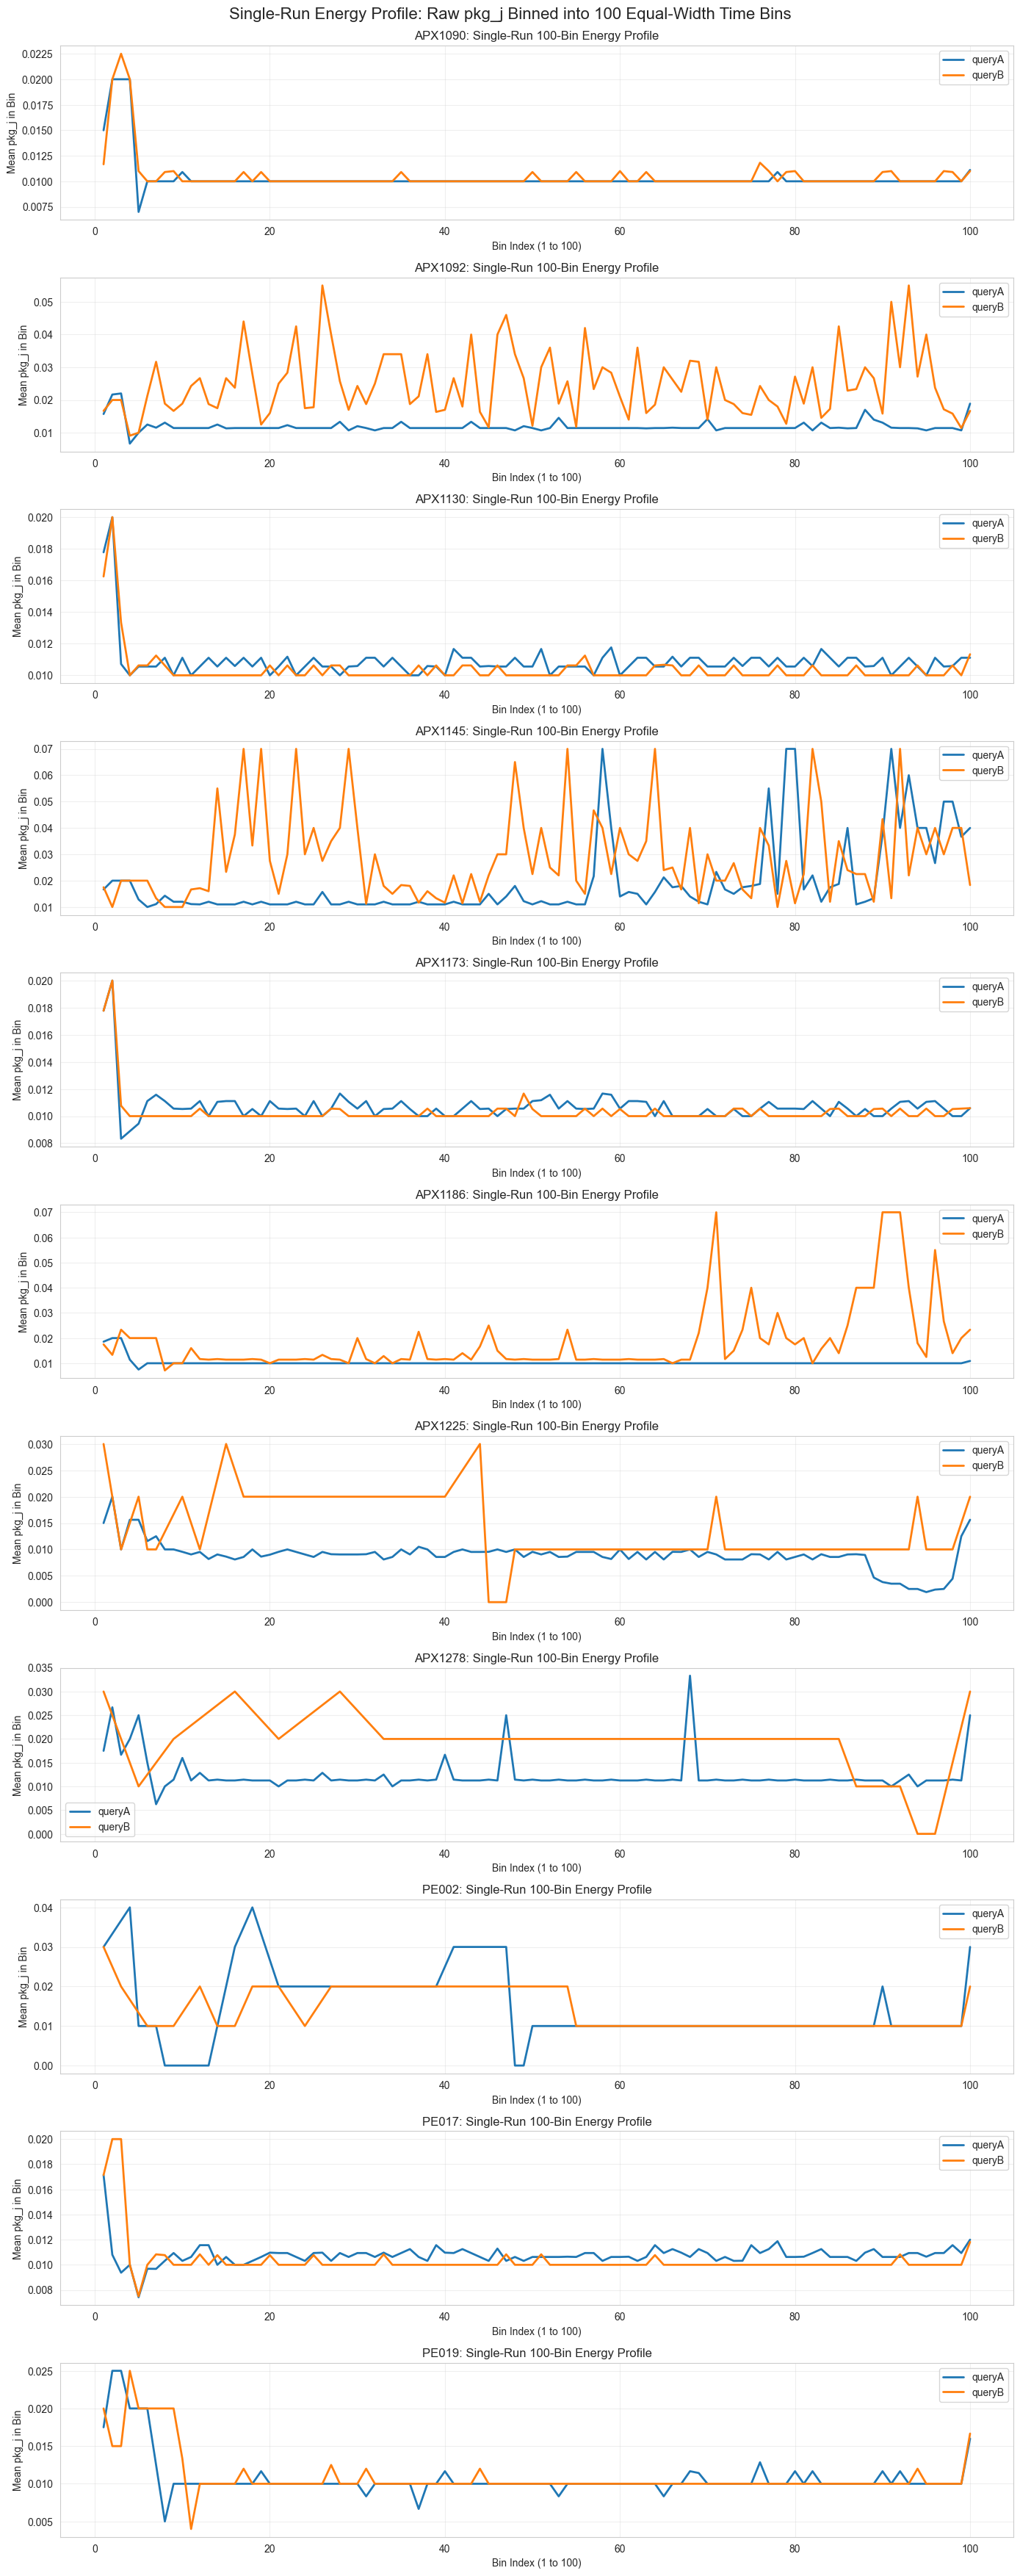

Single-run 100-bin comparison plot generated.
Found 22 loop file groups for machine B108631FEBA1ECD4
Starting plot 2: Full-loop 1-second binned comparison...


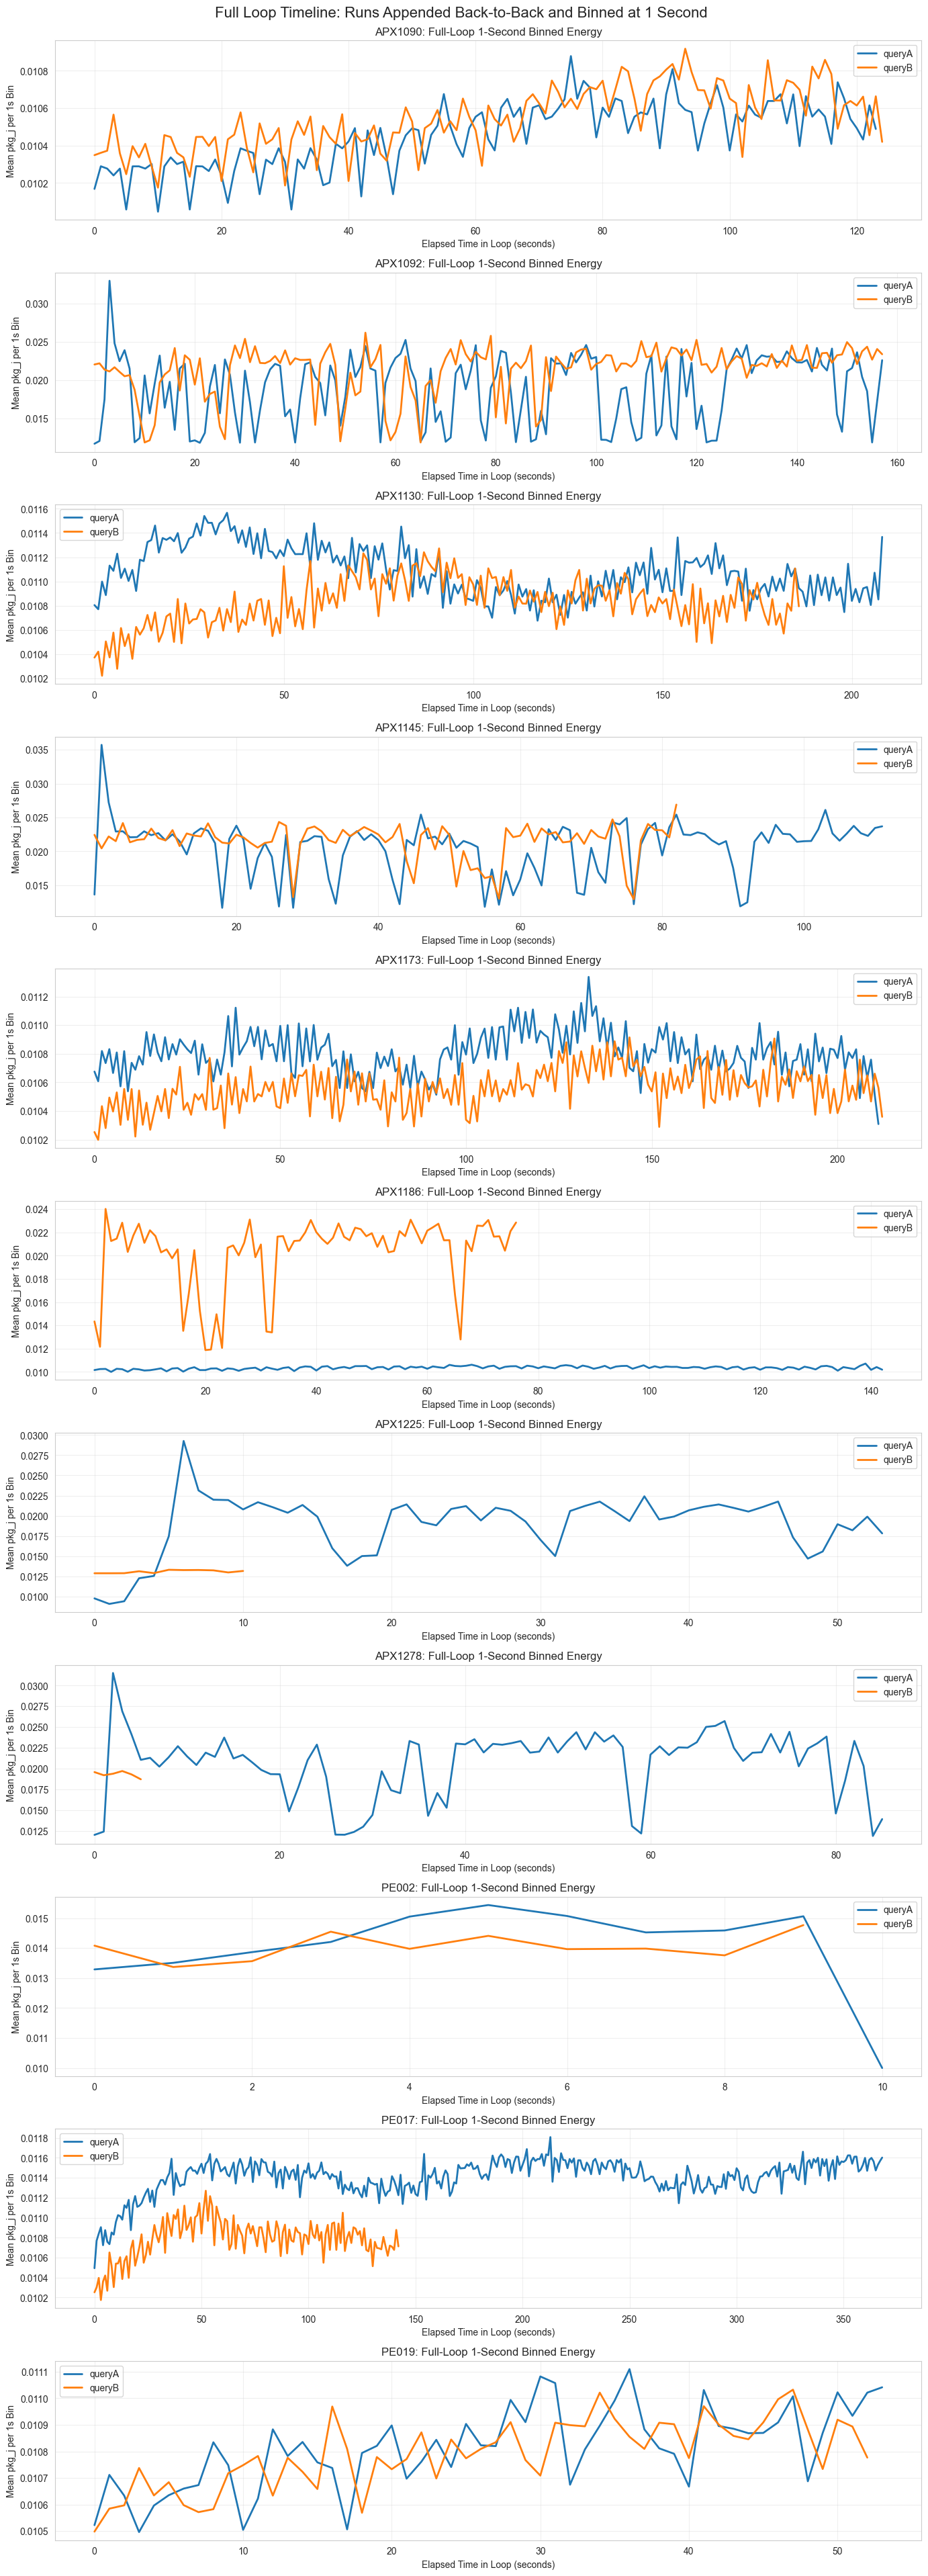

Full-loop 1-second binned comparison plot generated.


In [27]:
# Two requested views using raw pkg energy values from the sample CSVs:
# 1) A single representative run per query, binned into 100 equal-width bins.
# 2) A full loop timeline made by appending runs back-to-back, then binned at 1-second intervals.


def bin_single_run_to_100(filepath, n_bins=100):
    """Bin one run into a fixed number of equal-width time bins using raw pkg_j values."""
    df = load_sample(filepath)
    if df.empty or 'timestamp_sec' not in df.columns or 'pkg_j' not in df.columns:
        return None

    df = df[['timestamp_sec', 'pkg_j']].dropna().sort_values('timestamp_sec').copy()
    if len(df) < 2:
        return None

    start_t = float(df['timestamp_sec'].iloc[0])
    end_t = float(df['timestamp_sec'].iloc[-1])
    if end_t <= start_t:
        return None

    edges = np.linspace(start_t, end_t, n_bins + 1)
    bin_ids = np.digitize(df['timestamp_sec'].to_numpy(), edges, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    binned = pd.DataFrame({'bin_id': bin_ids, 'pkg_j': df['pkg_j'].to_numpy()})
    binned = binned.groupby('bin_id', as_index=False)['pkg_j'].mean()

    full_index = pd.RangeIndex(n_bins)
    binned = binned.set_index('bin_id').reindex(full_index)
    binned['pkg_j'] = binned['pkg_j'].interpolate(limit_direction='both')

    return np.arange(1, n_bins + 1), binned['pkg_j'].to_numpy(dtype=float)


# Build a representative run per test group and variant
MACHINE_ID_FILTER = "B108631FEBA1ECD4"
rep_runs = {tg: {'queryA': None, 'queryB': None} for tg in sorted(test_groups)}

found_tgs = set()
for sample_file in sample_files:
    machine_id, query_name, variant, test_group, run_info = extract_from_filename(sample_file.name)
    if machine_id != MACHINE_ID_FILTER:
        continue
    found_tgs.add(test_group)
    if test_group not in rep_runs or variant not in rep_runs[test_group]:
        continue
    if rep_runs[test_group][variant] is None:
        rep_runs[test_group][variant] = sample_file

print(f"Test groups in {MACHINE_ID_FILTER} files: {sorted(found_tgs)}")
print(f"Expected test groups: {test_groups}")
print(f"Found representative runs for {sum(1 for tg in test_groups if rep_runs[tg]['queryA'] or rep_runs[tg]['queryB'])} test groups")

# Plot 1: one run per group, 100 equal-width bins
print("Starting plot 1: 100-bin single-run comparison...")
fig, axes = plt.subplots(len(test_groups), 1, figsize=(14, 3.2 * len(test_groups)), squeeze=False)
fig.suptitle('Single-Run Energy Profile: Raw pkg_j Binned into 100 Equal-Width Time Bins', fontsize=16, y=0.995)

for idx, tg in enumerate(sorted(test_groups)):
    ax = axes[idx, 0]
    qa_file = rep_runs[tg]['queryA']
    qb_file = rep_runs[tg]['queryB']

    if qa_file is not None:
        x_bins, y_vals = bin_single_run_to_100(qa_file, n_bins=100)
        if x_bins is not None:
            ax.plot(x_bins, y_vals, color='#1f77b4', linewidth=2, label='queryA')

    if qb_file is not None:
        x_bins, y_vals = bin_single_run_to_100(qb_file, n_bins=100)
        if x_bins is not None:
            ax.plot(x_bins, y_vals, color='#ff7f0e', linewidth=2, label='queryB')

    ax.set_xlabel('Bin Index (1 to 100)')
    ax.set_ylabel('Mean pkg_j in Bin')
    ax.set_title(f'{tg}: Single-Run 100-Bin Energy Profile')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Single-run 100-bin comparison plot generated.')


# Plot 2: append all runs back-to-back, then bin every 1 second over the full loop timeline
run_info_re = re.compile(r'loop(\d+)_run(\d+)')


def parse_loop_run(run_info):
    m = run_info_re.fullmatch(run_info)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


loop_file_groups = {}
MACHINE_ID_FILTER = "B108631FEBA1ECD4"
for sample_file in sample_files:
    machine_id, query_name, variant, test_group, run_info = extract_from_filename(sample_file.name)
    if machine_id != MACHINE_ID_FILTER:
        continue
    if not test_group or not variant or not run_info:
        continue

    loop_idx, run_idx = parse_loop_run(run_info)
    if loop_idx is None or run_idx is None:
        continue

    key = (test_group, variant, machine_id, loop_idx)
    loop_file_groups.setdefault(key, []).append((run_idx, sample_file))

print(f"Found {len(loop_file_groups)} loop file groups for machine {MACHINE_ID_FILTER}")


def build_full_loop_timeline(files_sorted):
    """Append runs in time order and carry the timeline forward by each run's duration."""
    t_all = []
    v_all = []
    t_offset = 0.0

    for _, fp in files_sorted:
        df = load_sample(fp)
        if df.empty or 'timestamp_sec' not in df.columns or 'pkg_j' not in df.columns:
            continue

        df = df[['timestamp_sec', 'pkg_j']].dropna().sort_values('timestamp_sec').copy()
        if len(df) < 2:
            continue

        t = df['timestamp_sec'].to_numpy(dtype=float)
        v = df['pkg_j'].to_numpy(dtype=float)
        t = t - t[0]

        t_all.append(t + t_offset)
        v_all.append(v)
        t_offset += t[-1]

    if not t_all:
        return None, None

    return np.concatenate(t_all), np.concatenate(v_all)


def bin_by_one_second(t, v):
    """Average pkg_j values in 1-second bins."""
    sec = np.floor(t).astype(int)
    binned = pd.DataFrame({'sec': sec, 'pkg_j': v}).groupby('sec', as_index=False)['pkg_j'].mean()
    return binned['sec'].to_numpy(dtype=int), binned['pkg_j'].to_numpy(dtype=float)


loop_binned_curves = {tg: {'queryA': [], 'queryB': []} for tg in sorted(test_groups)}
for (tg, variant, machine_id, loop_idx), files in loop_file_groups.items():
    files_sorted = sorted(files, key=lambda x: x[0])
    t_loop, v_loop = build_full_loop_timeline(files_sorted)
    if t_loop is None:
        continue

    sec, vals = bin_by_one_second(t_loop, v_loop)
    loop_binned_curves[tg][variant].append((sec, vals))


print("Starting plot 2: Full-loop 1-second binned comparison...")
fig, axes = plt.subplots(len(test_groups), 1, figsize=(14, 3.5 * len(test_groups)), squeeze=False)
fig.suptitle('Full Loop Timeline: Runs Appended Back-to-Back and Binned at 1 Second', fontsize=16, y=0.995)

for idx, tg in enumerate(sorted(test_groups)):
    ax = axes[idx, 0]

    for variant, color in [('queryA', '#1f77b4'), ('queryB', '#ff7f0e')]:
        curves = loop_binned_curves[tg][variant]
        if not curves:
            continue

        # Usually there is one full loop trace per variant; if multiple exist, average them per second.
        max_sec = max(int(np.max(sec)) for sec, _ in curves)
        grid = np.arange(0, max_sec + 1, dtype=int)
        aligned = np.full((len(curves), len(grid)), np.nan, dtype=float)

        for i, (sec, vals) in enumerate(curves):
            aligned[i, sec] = vals

        med = np.nanmedian(aligned, axis=0)
        ax.plot(grid, med, color=color, linewidth=2, label=variant)

    ax.set_xlabel('Elapsed Time in Loop (seconds)')
    ax.set_ylabel('Mean pkg_j per 1s Bin')
    ax.set_title(f'{tg}: Full-Loop 1-Second Binned Energy')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Full-loop 1-second binned comparison plot generated.')

## Available Machine IDs

In [20]:
# List all unique machine IDs in sample files
machine_ids = set()
for sample_file in sample_files:
    machine_id, _, _, _, _ = extract_from_filename(sample_file.name)
    if machine_id:
        machine_ids.add(machine_id)

print(f"Available machine IDs: {sorted(machine_ids)}")
print(f"Total unique machines: {len(machine_ids)}")

Available machine IDs: ['AAB8C9E87643BCA5', 'B108631FEBA1ECD4', 'F7D202A0F76CE402', 'FD51FBFD2A1ADF7A']
Total unique machines: 4
